<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2023-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Exploratory Data Analysis Lab**


Estimated time needed: **30** minutes


In this module you get to work with the cleaned dataset from the previous module.

In this assignment you will perform the task of exploratory data analysis.
You will find out the distribution of data, presence of outliers and also determine the correlation between different columns in the dataset.


## Objectives


In this lab you will perform the following:


-   Identify the distribution of data in the dataset.

-   Identify outliers in the dataset.

-   Remove outliers from the dataset.

-   Identify correlation between features in the dataset.


* * *


## Hands on Lab


Import the pandas module.


In [1]:
import pandas as pd

Load the dataset into a dataframe.


In [2]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m2_survey_data.csv")

## Distribution


### Determine how the data is distributed


The column `ConvertedComp` contains Salary converted to annual USD salaries using the exchange rate on 2019-02-01.

This assumes 12 working months and 50 working weeks.


Plot the distribution curve for the column `ConvertedComp`.


In [6]:
import sys
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install matplotlib




Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


0     61000.0
1     95179.0
2     90000.0
3    455352.0
4     65277.0
Name: ConvertedComp, dtype: float64


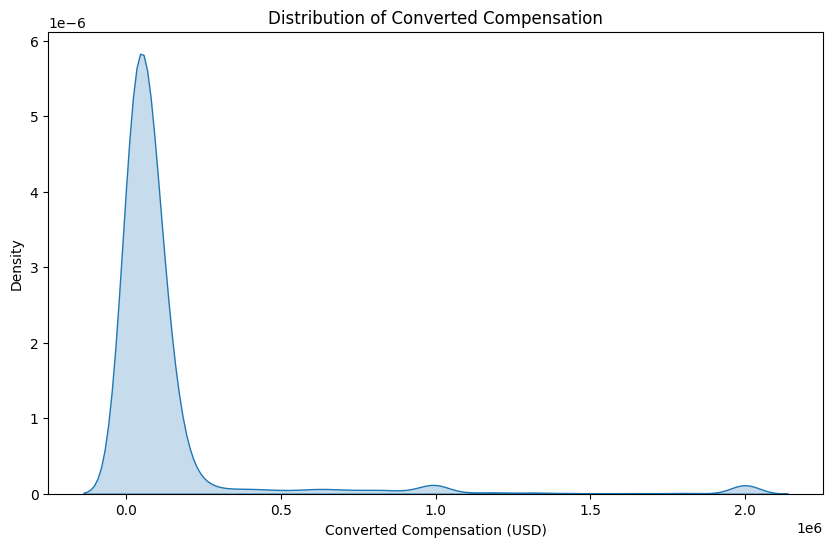

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df["ConvertedComp"].iloc[0:5])

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x="ConvertedComp", fill=True)

plt.title("Distribution of Converted Compensation")
plt.xlabel("Converted Compensation (USD)")
plt.ylabel("Density")

plt.show()

Plot the histogram for the column `ConvertedComp`.


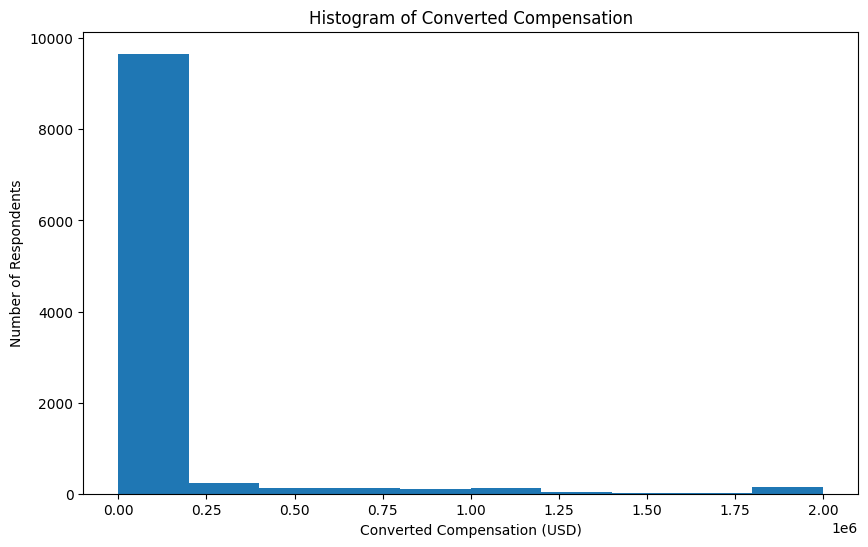

In [18]:
plt.figure(figsize=(10,6))

plt.hist(df["ConvertedComp"].dropna())

plt.title("Histogram of Converted Compensation")
plt.xlabel("Converted Compensation (USD)")
plt.ylabel("Number of Respondents")

plt.show()

What is the median of the column `ConvertedComp`?


In [9]:
print(df["ConvertedComp"].median())

57745.0


How many responders identified themselves only as a **Man**?


In [14]:
print(df["Gender"].value_counts())

man_count = (df["Gender"] == "Man").sum()
print(f"Man: {man_count}")

Gender
Man                                                            10480
Woman                                                            731
Non-binary, genderqueer, or gender non-conforming                 63
Man;Non-binary, genderqueer, or gender non-conforming             26
Woman;Non-binary, genderqueer, or gender non-conforming           14
Woman;Man                                                          9
Woman;Man;Non-binary, genderqueer, or gender non-conforming        2
Name: count, dtype: int64
Man: 10480


Find out the  median ConvertedComp of responders identified themselves only as a **Woman**?


In [15]:
median_woman_comp = df[df["Gender"] == "Woman"]["ConvertedComp"].median()
print(f"Median compensation for women: {median_woman_comp}")


Median compensation for women: 57708.0


Give the five number summary for the column `Age`?


**Double click here for hint**.

<!--
min,q1,median,q3,max of a column are its five number summary.
-->


In [16]:
df["Age"].describe()[["min", "25%", "50%", "75%", "max"]]

min    16.0
25%    25.0
50%    29.0
75%    35.0
max    99.0
Name: Age, dtype: float64

Plot a histogram of the column `Age`.


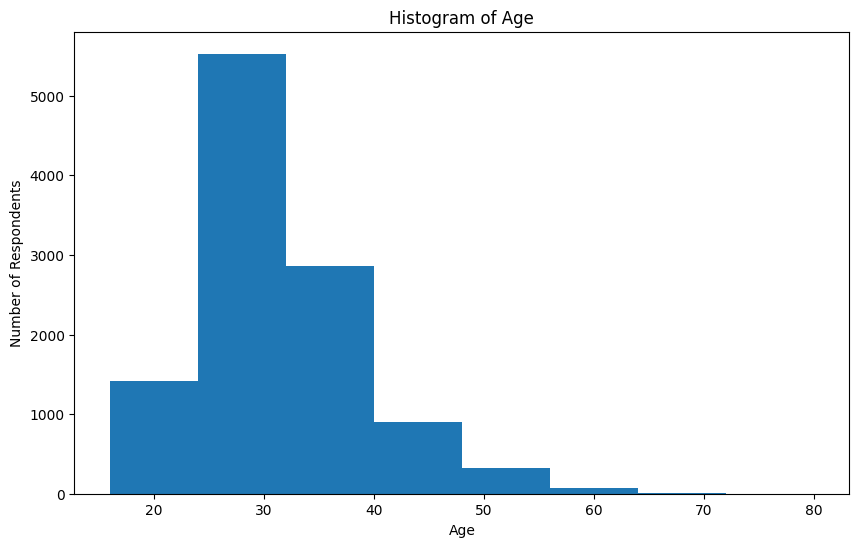

In [29]:
plt.figure(figsize=(10,6))

bins = [16, 24, 32, 40, 48, 56, 64, 72, 80]

plt.hist(df["Age"].dropna(), bins=bins)

plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Number of Respondents")

plt.show()

## Outliers


### Finding outliers


Find out if outliers exist in the column `ConvertedComp` using a box plot?


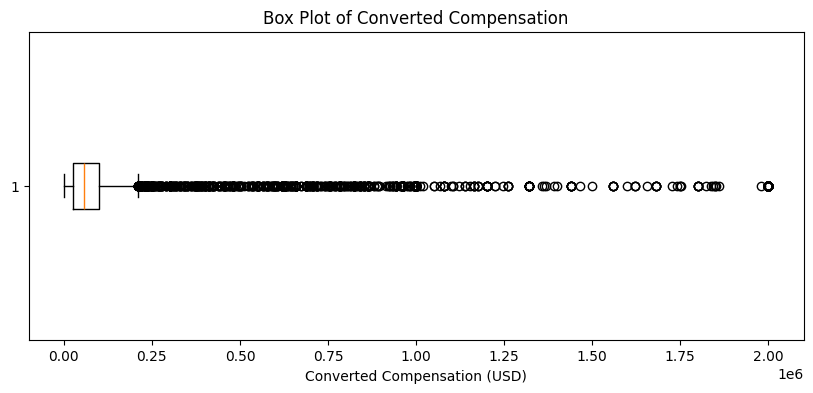

In [21]:
plt.figure(figsize=(10, 4))

plt.boxplot(df["ConvertedComp"].dropna(), vert=False)

plt.title("Box Plot of Converted Compensation")
plt.xlabel("Converted Compensation (USD)")

plt.show()


Find out the Inter Quartile Range for the column `ConvertedComp`.


In [22]:
Q1 = df["ConvertedComp"].quantile(0.25)
Q3 = df["ConvertedComp"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 26868.0
Q3: 100000.0
IQR: 73132.0


Find out the upper and lower bounds.


In [23]:
Q1 = df["ConvertedComp"].quantile(0.25)
Q3 = df["ConvertedComp"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -82830.0
Upper Bound: 209698.0


Identify how many outliers are there in the `ConvertedComp` column.


In [24]:
outliers = df[
    (df["ConvertedComp"] < lower_bound) |
    (df["ConvertedComp"] > upper_bound)
]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 879


Create a new dataframe by removing the outliers from the `ConvertedComp` column.


In [31]:
df_no_outliers = df[
    (df["ConvertedComp"] >= lower_bound) &
    (df["ConvertedComp"] <= upper_bound)
]

print(df.shape[0])
print(df_no_outliers.shape[0])
print(df_no_outliers["ConvertedComp"].median())
print(df_no_outliers["ConvertedComp"].mean())


11398
9703
52704.0
59883.20838915799


## Correlation


### Finding correlation


Find the correlation between `Age` and all other numerical columns.


In [28]:
correlations = df.corr(numeric_only=True)["Age"]

print(correlations)

Respondent       0.004041
CompTotal        0.006970
ConvertedComp    0.105386
WorkWeekHrs      0.036518
CodeRevHrs      -0.020469
Age              1.000000
Name: Age, dtype: float64


## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By        | Change Description                 |
| ----------------- | ------- | ----------------- | ---------------------------------- |
| 2020-10-17        | 0.1     | Ramesh Sannareddy | Created initial version of the lab |


 Copyright © 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2023-01-01&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ).
